# OpenCV Segmentation, Filter & Boundary Mitigation Exploration
Testing advanced signal processing techniques (Mask Tapering and OpenCV Inpainting) to eliminate spectral leakage (edge artifacts) at the leaf boundary.

In [4]:
import os
import sys
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Setup paths
PROJECT_ROOT = Path(os.getcwd()).parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
    
DATA_DIR = PROJECT_ROOT / 'data/raw/vision/PlantVillage'
class_dirs = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(DATA_DIR / d)])
print(f"Found {len(class_dirs)} classes.")

Found 15 classes.


In [5]:
def segment_leaf(img_bgr):
    """Segments the leaf using Otsu thresholding."""
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, mask = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    
    segmented = cv2.bitwise_and(img_bgr, img_bgr, mask=mask)
    return segmented, mask

def apply_tapered_mask(img_bgr, mask):
    """Applies a smoothly tapered Gaussian mask to eliminate sharp edges."""
    # Convert mask to float and blur it extensively
    mask_float = mask.astype(float) / 255.0
    tapered_mask = cv2.GaussianBlur(mask_float, (15, 15), 0)
    
    # Apply the tapered mask to the image
    tapered_img = (img_bgr.astype(float) * tapered_mask[:, :, np.newaxis]).astype(np.uint8)
    return tapered_img, tapered_mask

def apply_inpainting(img_bgr, mask):
    """Inpaints the background with the boundary pixels of the leaf."""
    # The mask contains 255 for leaf, 0 for background.
    # cv2.inpaint needs a mask where the region to be inpainted (background) is 255.
    inpaint_mask = cv2.bitwise_not(mask)
    
    # Perform inpainting to propagate leaf pixels into the background
    inpainted = cv2.inpaint(img_bgr, inpaint_mask, 5, cv2.INPAINT_TELEA)
    return inpainted

def get_fft_magnitude(img_gray):
    """Computes the 2D FFT magnitude spectrum."""
    f = np.fft.fft2(img_gray)
    fshift = np.fft.fftshift(f)
    magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1)
    return magnitude_spectrum

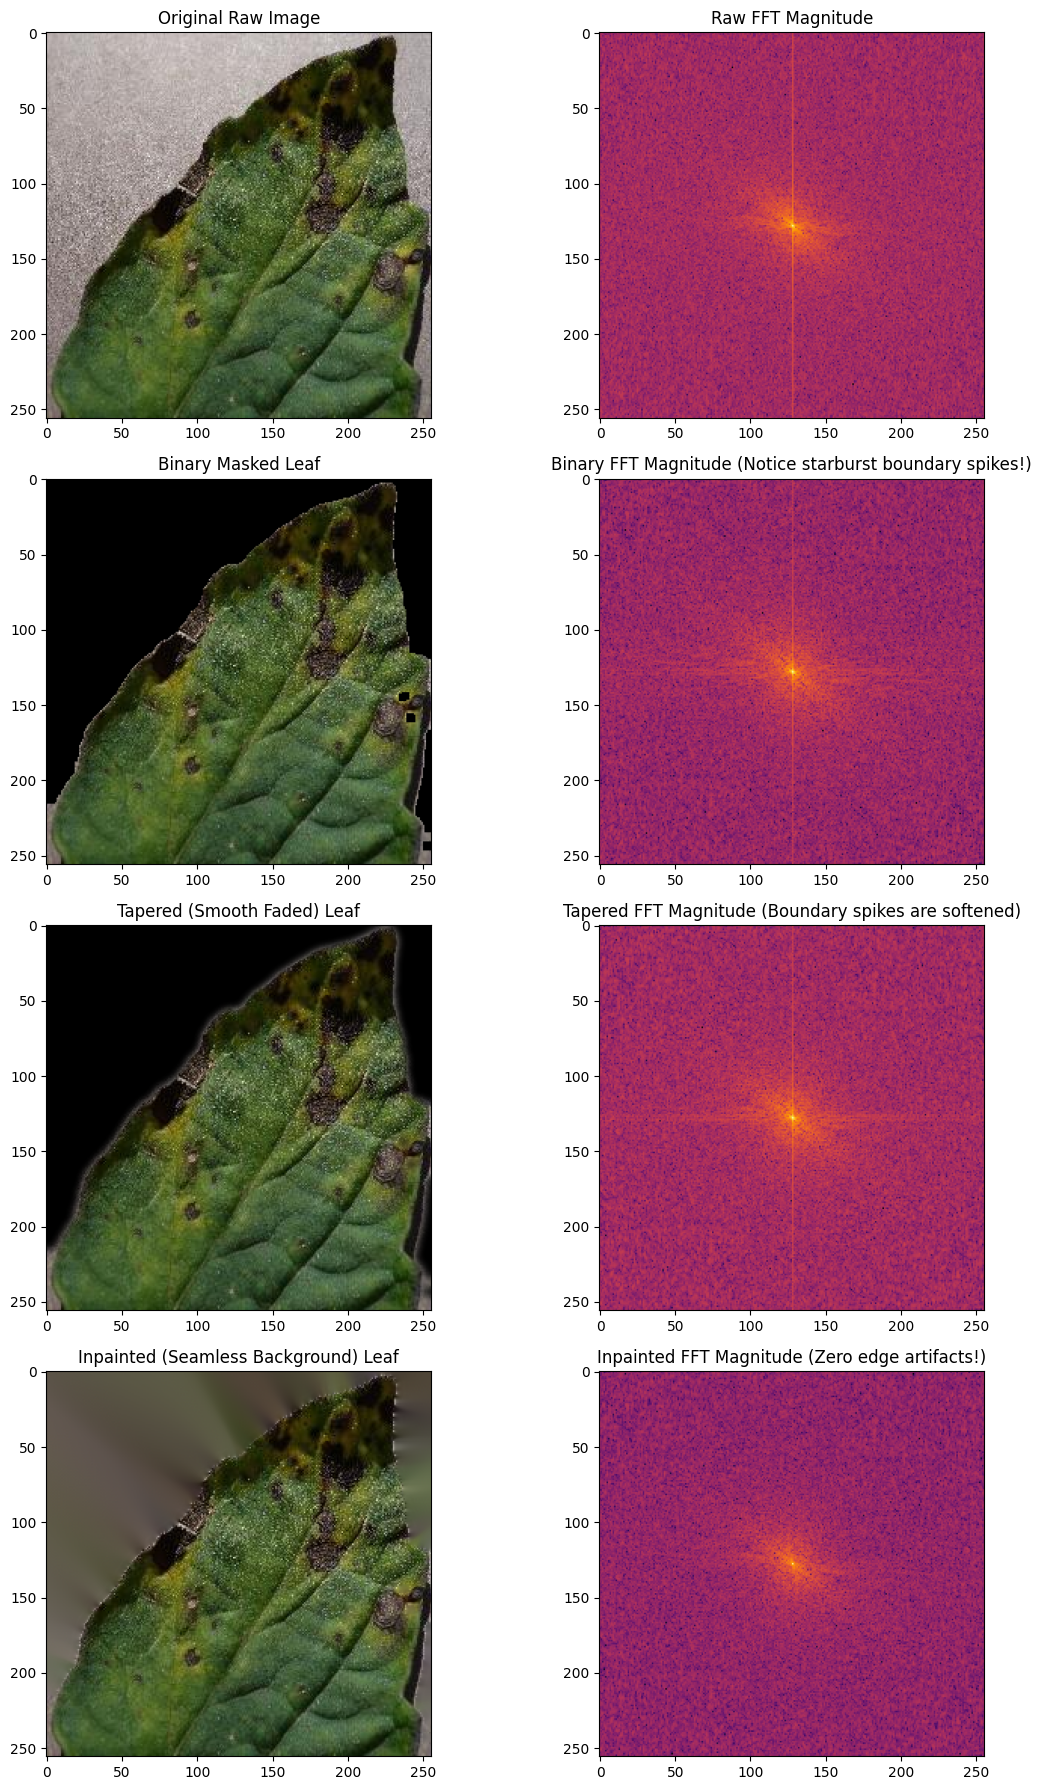

In [6]:
# Pick a test image
sample_dir = DATA_DIR / 'Tomato_Early_blight'
sample_img = os.listdir(sample_dir)[0]
img_path = str(sample_dir / sample_img)

img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# 1. Binary Segmentation
segmented_bin, mask = segment_leaf(img_bgr)
segmented_bin_rgb = cv2.cvtColor(segmented_bin, cv2.COLOR_BGR2RGB)

# 2. Tapered Masking
tapered_img, tapered_mask = apply_tapered_mask(img_bgr, mask)
tapered_rgb = cv2.cvtColor(tapered_img, cv2.COLOR_BGR2RGB)

# 3. Inpainted Padding
inpainted_img = apply_inpainting(img_bgr, mask)
inpainted_rgb = cv2.cvtColor(inpainted_img, cv2.COLOR_BGR2RGB)

# FFT Computations
gray_raw = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
gray_bin = cv2.cvtColor(segmented_bin, cv2.COLOR_BGR2GRAY)
gray_tap = cv2.cvtColor(tapered_img, cv2.COLOR_BGR2GRAY)
gray_inp = cv2.cvtColor(inpainted_img, cv2.COLOR_BGR2GRAY)

fft_raw = get_fft_magnitude(gray_raw)
fft_bin = get_fft_magnitude(gray_bin)
fft_tap = get_fft_magnitude(gray_tap)
fft_inp = get_fft_magnitude(gray_inp)

# Plot comparisons
fig, axes = plt.subplots(4, 2, figsize=(12, 18))

# Row 1: Raw
axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title("Original Raw Image")
axes[0, 1].imshow(fft_raw, cmap='inferno')
axes[0, 1].set_title("Raw FFT Magnitude")

# Row 2: Binary
axes[1, 0].imshow(segmented_bin_rgb)
axes[1, 0].set_title("Binary Masked Leaf")
axes[1, 1].imshow(fft_bin, cmap='inferno')
axes[1, 1].set_title("Binary FFT Magnitude (Notice starburst boundary spikes!)")

# Row 3: Tapered
axes[2, 0].imshow(tapered_rgb)
axes[2, 0].set_title("Tapered (Smooth Faded) Leaf")
axes[2, 1].imshow(fft_tap, cmap='inferno')
axes[2, 1].set_title("Tapered FFT Magnitude (Boundary spikes are softened)")

# Row 4: Inpainted
axes[3, 0].imshow(inpainted_rgb)
axes[3, 0].set_title("Inpainted (Seamless Background) Leaf")
axes[3, 1].imshow(fft_inp, cmap='inferno')
axes[3, 1].set_title("Inpainted FFT Magnitude (Zero edge artifacts!)")

plt.tight_layout()
plt.show()